In [2]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [3]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [4]:
import MieLibrary as mie

In [14]:
cset_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/CSET/","*.nc"))
cset_loc_tag = "RWOOU"

socrates_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/SOCRATES/","*.nc"))
soc_loc_tag = "CVIU"

hippo1_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-1","*.nc"))
hippo1_loc_tag = "RWI"

hippo2_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-2","*.nc"))
hippo2_loc_tag = "RWI"

hippo3_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-3","*.nc"))
hippo3_loc_tag = "RWI"

hippo4_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-4","*.nc"))
hippo4_loc_tag = "RWI"

hippo5_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-5","*.nc"))
hippo5_loc_tag = "RWI"

In [68]:
wavelen_lst = [1064e-9, 532e-9, 355e-9]
wavelen_color = ['tab:red', 'tab:green','tab:purple']
index_refrac = 1.5

In [74]:
number_conc_lst = []
mean_r_lst = []
mean_r_2_lst = []
mean_r_3_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []
file_name_lst = []
proj_name_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []
aircraft_vars_attrs = {}

# postfix = 'RWOOU'  # CSET
# postfix = 'CVIU'   # SOCRATES
# postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5

# TODO also read in GGLAT, GGLON, GGALT

# file_lst = cset_lst
# file_lst = socrates_lst[4:5]
# file_lst = hippo1_lst
# file_lst = hippo2_lst
# file_lst = hippo4_lst
# file_lst = hippo5_lst

project_file_lst = [hippo1_lst, hippo2_lst, hippo3_lst, hippo4_lst, hippo5_lst]
project_str_lst = ['HIPPO-1', 'HIPPO-2', 'HIPPO-3', 'HIPPO-4', 'HIPPO-5',]
postfix_lst = [hippo1_loc_tag, hippo2_loc_tag, hippo3_loc_tag, hippo4_loc_tag, hippo5_loc_tag]


load_params = True

for project_idx, file_lst in enumerate(project_file_lst):
    postfix = postfix_lst[project_idx]
    project_str = project_str_lst[project_idx]

    for fidx,file in enumerate(file_lst):
        ds = xr.open_dataset(file)
        load_file = True
        
        if load_params:
            # run all the initial calculations
            try:
                part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
                # load_params = False
                r_arr = part_diam/2
                ang_arr = np.linspace(0,500e-6,100)
                dang=np.diff(ang_arr)
                solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
                r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
        
                sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
                sig_e = np.zeros((len(wavelen_lst),r_arr.size))
                
                for wl_idx, wavelen in enumerate(wavelen_lst):
                    k_num = 2*np.pi/wavelen
                    for r_idx,r_val in enumerate(r_arr):
                        x_val = 2*np.pi*r_val/wavelen  # particle size parameter
                        Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                        sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr)) # backscatter
                        sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2  # extinction
            except KeyError:
                load_file = False
                print("Cannot load " + file)
    
        # skip loading the data if there is no UHSAS data
        if load_file:
            # dataset calculations
            beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            for idx in range(len(wavelen_lst)):
                beta_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
                alpha_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
            number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)
            
            mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
            mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
            mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
            mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
            std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
        
            valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
            for var in aircraft_vars_dct:
                aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
                aircraft_vars_attrs[var] = ds[var].attrs
        
            beta_coef_lst.append(beta_coef[:,valid_idx[0]])
            alpha_coef_lst.append(alpha_coef[:,valid_idx[0]])
            number_conc_lst.append(number_conc[valid_idx[0]])
            mean_r_lst.append(mean_r[valid_idx[0]])
            mean_r_2_lst.append(mean_r_2[valid_idx[0]])
            mean_r_3_lst.append(mean_r_3[valid_idx[0]])
            mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
            std_ln_r_lst.append(std_ln_r[valid_idx[0]])
            file_name_lst.append([file.split(os.sep)[-1]]*len(valid_idx[0]))
            proj_name_lst.append([project_str]*len(valid_idx[0]))
            # file_name_lst.append(file.split(os.sep)[-1])
            # proj_name_lst.append(project_str)

/tmp/ipykernel_4043102/3662277836.py:81: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:82: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:83: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:84: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:85: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number

Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf01.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf02.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf03.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf04.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf05.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf06.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf07.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf08.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf09.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf10.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf11.nc


/tmp/ipykernel_4043102/3662277836.py:81: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:82: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:83: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:84: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_4043102/3662277836.py:85: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number

In [76]:
lidar_wl_str_lst = [f"{x*1e9:.02f}" for x in wavelen_lst]
aer_ds = xr.Dataset({},
           attrs={
               'description':'UHSAS aerosol data products of mean radius and number concentration and estimated lidar backscatter and extinction',
               'projects': ', '.join(np.unique(np.concatenate(proj_name_lst))),
               'lidar_wavelengths': ', '.join(lidar_wl_str_lst),
           }
          )

In [77]:
aer_ds['wavelength'] = xr.DataArray(wavelen_lst,
                                    dims=('wavelength',),
                                    attrs = {'description':'wavelength used to calculate scattering and extinction parameters',
                                             'units':'m',
                                            })
aer_ds['data_index'] = xr.DataArray(np.arange(np.concatenate(number_conc_lst,).size),dims=('data_index',),
                                    attrs = {'description':'index to data point in the dataset',})

aer_ds['backscatter_coefficient'] = xr.DataArray(np.concatenate(beta_coef_lst,axis=1),dims=('wavelength','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume backscatter coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1} sr^{-1}',}
                                                )
aer_ds['extinction_coefficient'] = xr.DataArray(np.concatenate(alpha_coef_lst,axis=1),dims=('wavelength','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume extinction coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1}',}
                                                )
aer_ds['number_concentration'] = xr.DataArray(np.concatenate(number_conc_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Number concentration of the aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'cm^{-3}',})

aer_ds['mean_r'] = xr.DataArray(np.concatenate(mean_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m',})

aer_ds['mean_r_2'] = xr.DataArray(np.concatenate(mean_r_2_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of second moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^2',})

aer_ds['mean_r_3'] = xr.DataArray(np.concatenate(mean_r_3_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of third moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^3',})

aer_ds['std_ln_r'] = xr.DataArray(np.concatenate(std_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'standard deviation of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['mean_log_r'] = xr.DataArray(np.concatenate(mean_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['file_name'] = xr.DataArray(np.concatenate(file_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of data file the UHSAS aerosol distribution came from',
                                                          'units':'None',})
aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
                                                          'units':'None',})

aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
                                                          'units':'None',})
for var in aircraft_vars_dct:
    aer_ds[var] = xr.DataArray(np.concatenate(aircraft_vars_dct[var]),dims=('data_index',),
                                                     coords = {'data_index':aer_ds['data_index']},
                                                     attrs = aircraft_vars_attrs[var])

In [79]:
aer_ds.to_netcdf('/scr/tmp/mhayman/hippo_aerosol_training_data.nc')

'HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5'

In [38]:
cov_mat = np.cov(np.concatenate([np.concatenate(alpha_coef_lst,axis=1),
                np.concatenate(beta_coef_lst,axis=1),
                np.concatenate(number_conc_lst,).reshape(1,-1),
                np.concatenate(mean_r_lst).reshape(1,-1)],axis=0))

In [40]:
cov_mat

array([[4.09142499e-11, 1.14114828e-10, 1.40079472e-10, 1.32121206e-12,
        4.95782180e-12, 1.10849105e-11, 1.92956929e-03, 2.34003793e-14],
       [1.14114828e-10, 3.36314466e-10, 4.29455538e-10, 3.91474646e-12,
        1.40728938e-11, 3.15436354e-11, 6.21956435e-03, 7.13228391e-14],
       [1.40079472e-10, 4.29455538e-10, 5.70300232e-10, 5.08094552e-12,
        1.76838717e-11, 3.95135236e-11, 8.95314928e-03, 9.40218675e-14],
       [1.32121206e-12, 3.91474646e-12, 5.08094552e-12, 4.63454811e-14,
        1.64759462e-13, 3.67907433e-13, 7.72646816e-05, 8.43512204e-16],
       [4.95782180e-12, 1.40728938e-11, 1.76838717e-11, 1.64759462e-13,
        6.10629975e-13, 1.35693025e-12, 2.58511788e-04, 2.90103249e-15],
       [1.10849105e-11, 3.15436354e-11, 3.95135236e-11, 3.67907433e-13,
        1.35693025e-12, 3.03901580e-12, 5.74408692e-04, 6.52544793e-15],
       [1.92956929e-03, 6.21956435e-03, 8.95314928e-03, 7.72646816e-05,
        2.58511788e-04, 5.74408692e-04, 2.87853109e+05, 9.

In [50]:
cor_mat = np.corrcoef(np.concatenate([np.concatenate(alpha_coef_lst,axis=1),
                np.concatenate(beta_coef_lst,axis=1),
                np.concatenate(number_conc_lst,).reshape(1,-1),
                np.concatenate(mean_r_lst).reshape(1,-1)],axis=0))

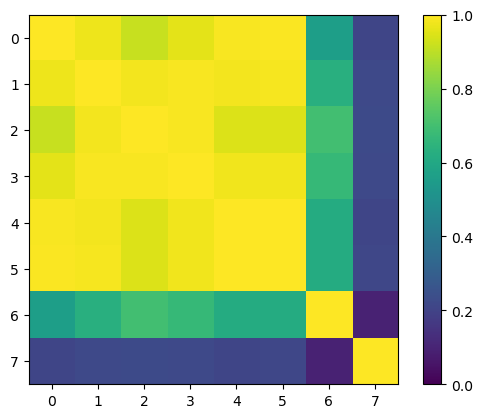

In [51]:
plt.figure()
plt.imshow(cor_mat,vmin=0,vmax=1)
plt.colorbar()

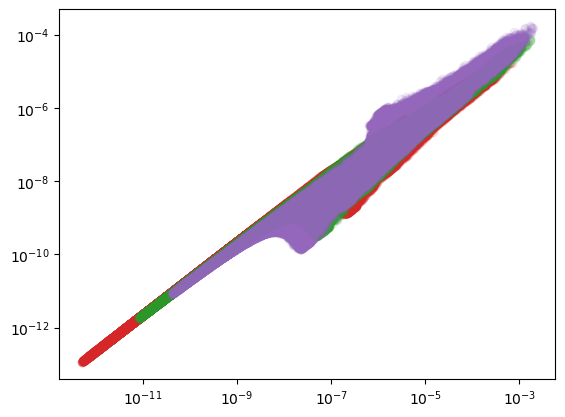

In [37]:
plt.figure()
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[0,:],np.concatenate(beta_coef_lst,axis=1)[0,:],c=wavelen_color[0],alpha=0.1)
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[1,:],np.concatenate(beta_coef_lst,axis=1)[1,:],c=wavelen_color[1],alpha=0.1)
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[2,:],np.concatenate(beta_coef_lst,axis=1)[2,:],c=wavelen_color[2],alpha=0.1)
plt.xscale('log')
plt.yscale('log')

In [35]:
beta_coef_lst[1].shape

(3, 18849)

In [18]:
part_diam

array([7.50000027e-08, 7.69899984e-08, 7.90300021e-08, 8.11199996e-08,
       8.32699953e-08, 8.54799964e-08, 8.77500028e-08, 9.00700030e-08,
       9.24599988e-08, 9.49099999e-08, 9.74299965e-08, 1.00009999e-07,
       1.02660003e-07, 1.05389994e-07, 1.08180004e-07, 1.11049999e-07,
       1.36899999e-07, 1.40530005e-07, 1.44260000e-07, 1.48080005e-07,
       1.52009989e-07, 1.56040002e-07, 1.60170003e-07, 1.64419987e-07,
       1.68780005e-07, 1.73250001e-07, 1.77839993e-07, 1.82560001e-07,
       1.87400005e-07, 1.92369995e-07, 1.97469987e-07, 2.02700008e-07,
       2.08069991e-07, 2.13589999e-07, 2.63320004e-07, 2.70300006e-07,
       2.77469979e-07, 2.84819976e-07, 2.92370004e-07, 3.00120007e-07,
       3.08079990e-07, 3.16250009e-07, 3.24629980e-07, 3.33239996e-07,
       3.42070024e-07, 3.51139988e-07, 3.60450002e-07, 3.70000009e-07,
       3.79810018e-07, 3.89880000e-07, 4.00220017e-07, 4.10829983e-07,
       4.21719989e-07, 4.32900009e-07, 4.44369988e-07, 4.56149991e-07,
      

In [19]:
file

'/scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf01.nc'

In [20]:
ds

<xarray.Dataset>
Dimensions:                 (Time: 22707, sps1: 1, Vector31: 31,
                             interarrival_endpoints: 41, Vector129: 129)
Coordinates:
  * Time                    (Time) datetime64[ns] 2009-10-31T16:20:30 ... 200...
  * interarrival_endpoints  (interarrival_endpoints) float32 1e-07 ... 10.0
Dimensions without coordinates: sps1, Vector31, Vector129
Data variables: (12/156)
    ACDP_LWI                (Time, sps1, Vector31) float32 ...
    ADIFR                   (Time) float32 ...
    BDIFR                   (Time) float32 ...
    BLATA                   (Time) float32 ...
    BLONGA                  (Time) float32 ...
    BNORMA                  (Time) float32 ...
    ...                      ...
    NACCEPT2DCR_LWO         (Time) float32 ...
    NACCEPT2DCA_LWO         (Time) float32 ...
    NREJECT2DCR_LWO         (Time) float32 ...
    NREJECT2DCA_LWO         (Time) float32 ...
    WIF                     (Time) float32 ...
    WIX                     (Time) float32 ...
Attributes: (12/40)
    institution:                   NCAR Research Aviation Facility
    Address:                       P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                         (303) 497-1030
    creator_url:                   http://www.eol.ucar.edu
    creator_email:                 codiac at ucar.edu
    Conventions:                   NCAR-RAF/nimbus
    ...                            ...
    landmarks:                     39.9083 -105.116 BJC,61.1741 -149.996 ANC,...
    Categories:                    Position,Thermodynamic,Aircraft State,Atmo...
    time_coverage_start:           2009-10-31T16:20:30 +0000
    time_coverage_end:             2009-10-31T22:38:56 +0000
    history:                       Thu Nov 10 02:20:22 2016: ncks -a -v ^.*1D...
    NCO:                           4.4.4

In [66]:
number_conc_lst

[array([1035.3445 ,  862.2571 ,  810.35626, ...,  257.39334,  252.14883,
         260.06305], dtype=float32),
 array([12.294673 ,  7.6809835, 21.509579 , ..., 19.614937 , 23.12051  ,
        21.305452 ], dtype=float32),
 array([   9.355981,   15.604578,    9.35429 , ..., 3670.971   ,
        4282.6074  , 5405.5225  ], dtype=float32),
 array([320.44775 , 348.523   , 253.25835 , ..., 106.613014, 123.37335 ,
         99.97107 ], dtype=float32),
 array([347.40222, 330.35187, 379.15717, ..., 158.14789, 155.99559,
        120.61643], dtype=float32),
 array([168.89279, 195.83488, 166.24146, ..., 197.40631, 212.53677,
        190.83716], dtype=float32),
 array([1027.6367 ,  814.9708 ,  865.48114, ...,  787.029  ,  854.0676 ,
         970.48694], dtype=float32),
 array([1622.2311 , 1277.7161 , 1347.5562 , ...,  367.35068,  405.08478,
         543.5119 ], dtype=float32),
 array([890.7566  , 908.8982  , 831.55524 , ...,  28.851833,  24.50832 ,
         31.765982], dtype=float32),
 array([117.6736